In [1]:
from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/srv/sferraro/choreographer/")

import envs
from envs.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

import mani_skill2
import mani_skill2.envs


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/robosuite-1.4.0-py3.8.egg/robosuite/scripts/setup_macros.py (__init__.py:9)


In [2]:
# Import agent model (WM + Actor Critic)
agent_path = Path(f'/srv/sferraro/choreographer/notebooks/object_pos_debug/models/intr/last_snapshot.pt')

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
        agent.device = device
        agent.wm.device = device
        agent.wm.rssm.device = device
        agent.wm.rssm._cell.device = device
    return agent, step

agent, global_step = load_agent(agent_path)

In [3]:
from hydra import compose, initialize
from omegaconf import OmegaConf

initialize(config_path="../../exp_local/2023.05.11/114829_dreamer_obj_rsPanda_CustomLift_/.hydra", job_name="config")
cfg = compose(config_name="config")

In [4]:
# Agent parametrization
obs_type = agent.cfg.obs_type
action_repeat = agent.cfg.action_repeat
snapshot_ts = global_step * action_repeat

agent.reward_free = True

agent.use_selector = False
agent.detached_exploration = True

seed = agent.cfg.seed

task = "rsPanda_CustomLift"
domain = task.split("_")[0]

cfg.env.objects.minsize = 0.025

# Env creation
eval_env = make(task, obs_type, frame_stack=1, 
                    action_repeat=action_repeat, seed=seed, env_config=cfg.env)

/home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/gym/spaces/box.py:73: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(


  0%|          | 0/1 [00:00<?, ?it/s]

Cube position: [ 0.01423671 -0.0269892   0.8528468 ]
Predicted position: [[-0.05959402 -0.0214235   0.88980407]]
Pixels in view: 42
Contact: False


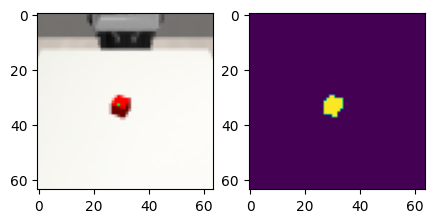

Cube position: [ 0.01612974 -0.02688402  0.8547842 ]
Predicted position: [[-0.07827564 -0.02805959  0.8924709 ]]
Pixels in view: 42
Contact: False


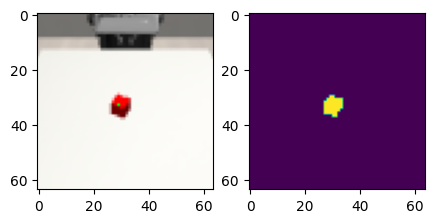

Cube position: [ 0.01653404 -0.02686156  0.85519797]
Predicted position: [[-0.08154606 -0.02901995  0.89102846]]
Pixels in view: 42
Contact: False


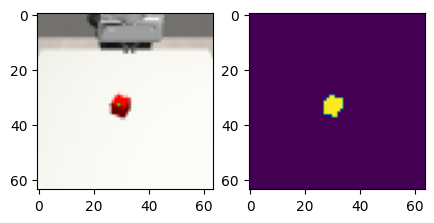

Cube position: [ 0.01663169 -0.02685613  0.8552979 ]
Predicted position: [[-0.07729622 -0.03045079  0.89072037]]
Pixels in view: 43
Contact: False


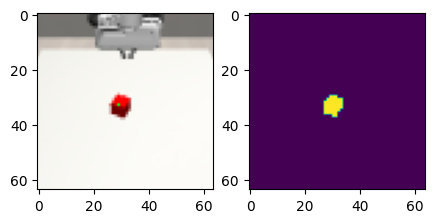

Cube position: [ 0.01665985 -0.02685457  0.8553268 ]
Predicted position: [[-0.07493417 -0.02937006  0.8903099 ]]
Pixels in view: 44
Contact: False


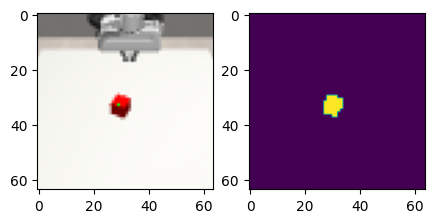

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.07643042 -0.03205318  0.8899961 ]]
Pixels in view: 44
Contact: False


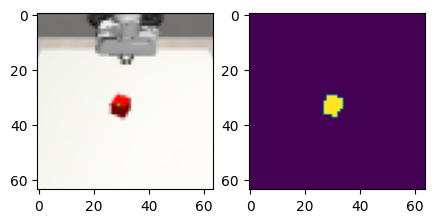

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.07656625 -0.02903624  0.89016545]]
Pixels in view: 44
Contact: False


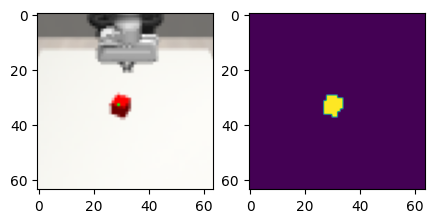

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.0703419  -0.03251765  0.8909135 ]]
Pixels in view: 44
Contact: False


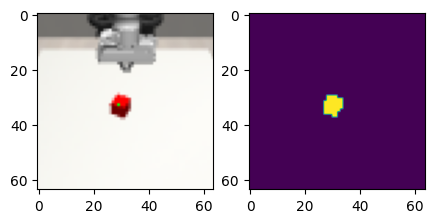

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.07293084 -0.03213391  0.8903997 ]]
Pixels in view: 44
Contact: False


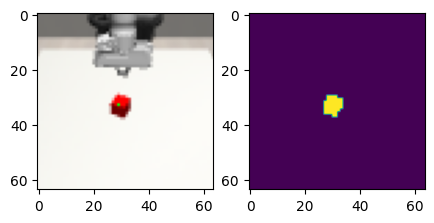

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.0743015  -0.03294417  0.89053595]]
Pixels in view: 44
Contact: False


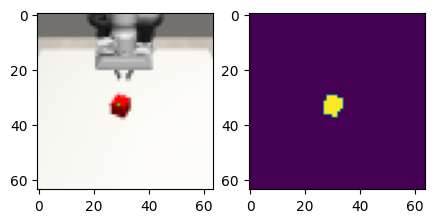

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.07012644 -0.03458674  0.88939834]]
Pixels in view: 44
Contact: False


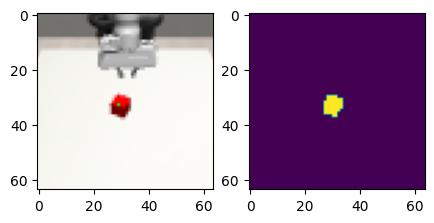

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.07270468 -0.03706827  0.889712  ]]
Pixels in view: 44
Contact: False


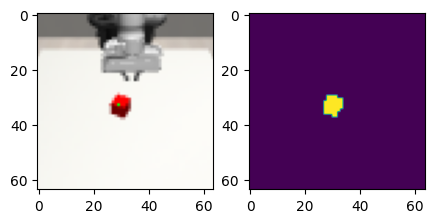

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.07311577 -0.03712391  0.88973904]]
Pixels in view: 44
Contact: False


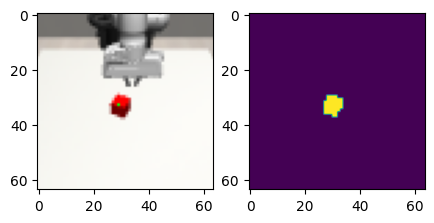

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.0692878  -0.03728113  0.890064  ]]
Pixels in view: 44
Contact: False


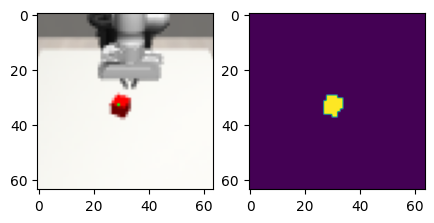

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.06556129 -0.03590981  0.89021355]]
Pixels in view: 44
Contact: False


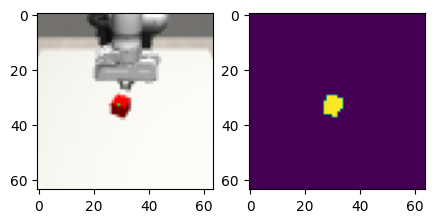

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.06175674 -0.03471521  0.88948095]]
Pixels in view: 44
Contact: False


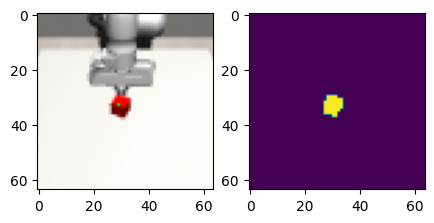

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.05983562 -0.03354645  0.8895198 ]]
Pixels in view: 42
Contact: False


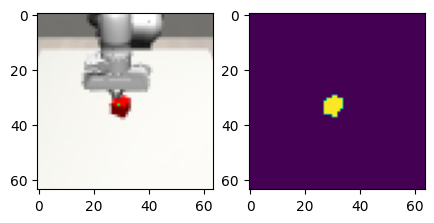

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.05907187 -0.03343315  0.889709  ]]
Pixels in view: 41
Contact: False


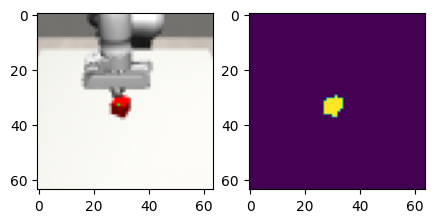

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.05739623 -0.03277081  0.8906312 ]]
Pixels in view: 36
Contact: False


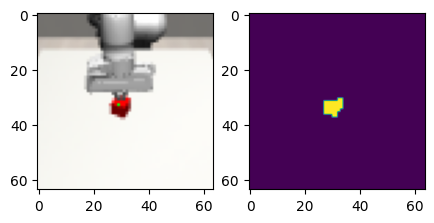

Cube position: [ 0.01666739 -0.01790277  0.85533446]
Predicted position: [[-0.05737016 -0.03466994  0.8905734 ]]
Pixels in view: 38
Contact: False


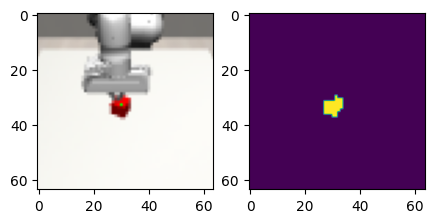

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.05953339 -0.03496741  0.88925457]]
Pixels in view: 41
Contact: False


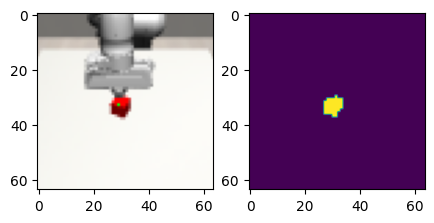

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.05613241 -0.03561528  0.889544  ]]
Pixels in view: 40
Contact: False


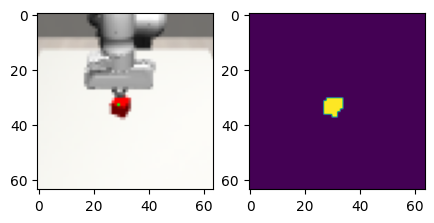

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.05681936 -0.03634898  0.8894551 ]]
Pixels in view: 42
Contact: False


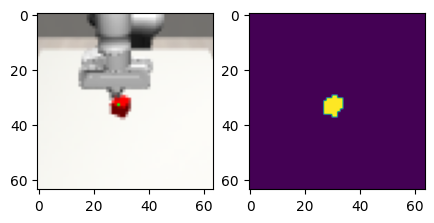

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.05495073 -0.03387421  0.89051163]]
Pixels in view: 44
Contact: False


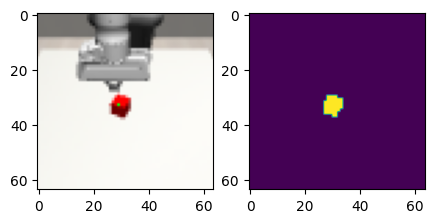

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.05603416 -0.03944271  0.89205945]]
Pixels in view: 44
Contact: False


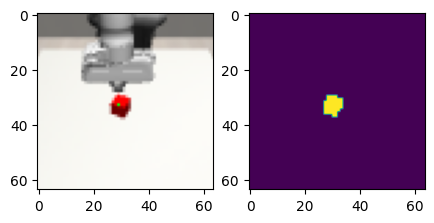

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.0597157  -0.04064432  0.89212483]]
Pixels in view: 44
Contact: False


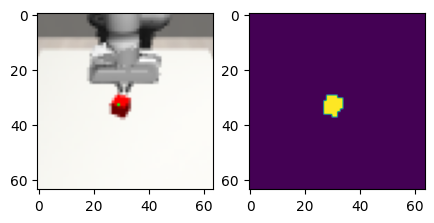

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.06060725 -0.04253335  0.89133126]]
Pixels in view: 44
Contact: False


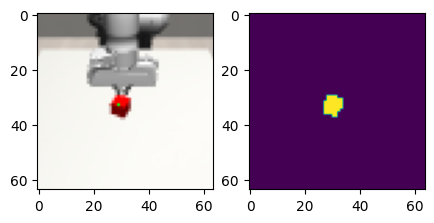

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.06087953 -0.03934079  0.89086294]]
Pixels in view: 37
Contact: False


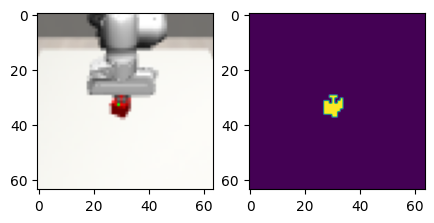

Cube position: [ 0.01374699 -0.02737441  0.8392901 ]
Predicted position: [[-0.06094203 -0.03485555  0.89056873]]
Pixels in view: 32
Contact: True


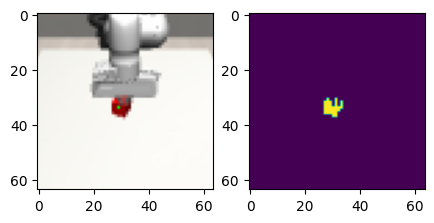

Cube position: [ 0.01523794 -0.02693357  0.85387146]
Predicted position: [[-0.06362835 -0.03841383  0.889753  ]]
Pixels in view: 40
Contact: False


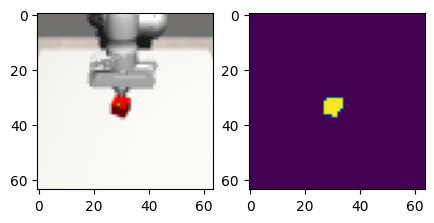

Cube position: [ 0.016316   -0.02687367  0.8549748 ]
Predicted position: [[-0.06499258 -0.03937417  0.8892043 ]]
Pixels in view: 42
Contact: False


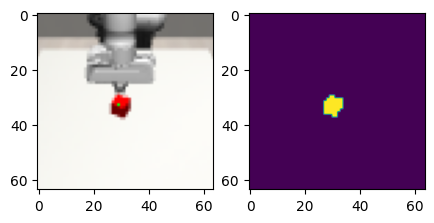

Cube position: [ 0.01657912 -0.02685905  0.8552441 ]
Predicted position: [[-0.06074836 -0.03992824  0.88976955]]
Pixels in view: 41
Contact: False


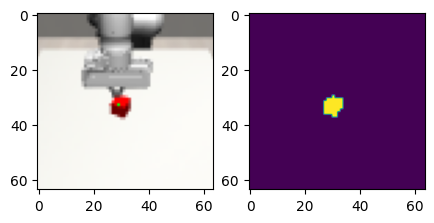

Cube position: [ 0.01663731 -0.01790388  0.8553037 ]
Predicted position: [[-0.06292891 -0.03556825  0.89052033]]
Pixels in view: 38
Contact: False


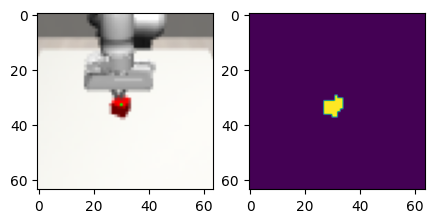

Cube position: [ 0.0166561  -0.02685478  0.8553229 ]
Predicted position: [[-0.06222207 -0.03812249  0.890985  ]]
Pixels in view: 42
Contact: False


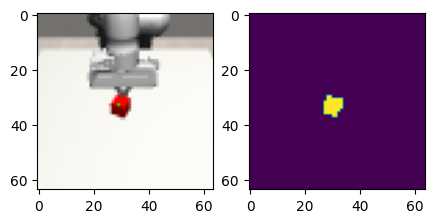

Cube position: [ 0.01666173 -0.02685446  0.8553287 ]
Predicted position: [[-0.06237581 -0.03862669  0.8906613 ]]
Pixels in view: 44
Contact: False


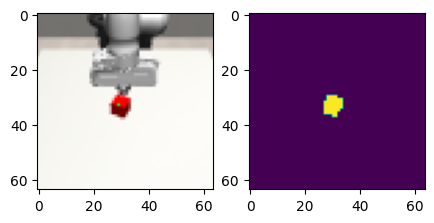

Cube position: [ 0.01666173 -0.02685446  0.8553287 ]
Predicted position: [[-0.06363284 -0.03898859  0.8902539 ]]
Pixels in view: 40
Contact: False


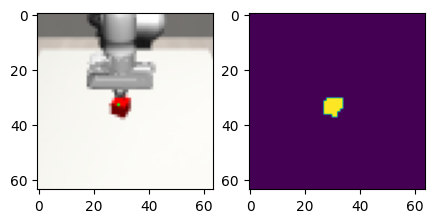

Cube position: [ 0.01666173 -0.02685446  0.8553287 ]
Predicted position: [[-0.05838137 -0.03780919  0.890225  ]]
Pixels in view: 42
Contact: False


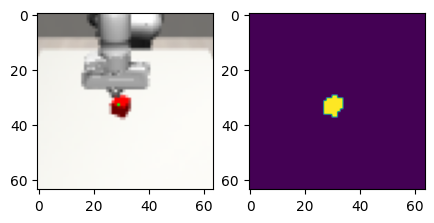

Cube position: [ 0.01666173 -0.02685446  0.8553287 ]
Predicted position: [[-0.06002227 -0.03610685  0.8892447 ]]
Pixels in view: 44
Contact: False


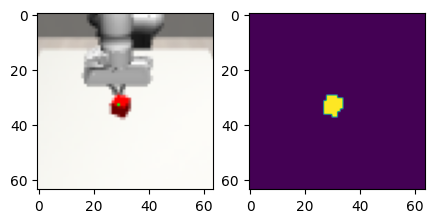

Cube position: [ 0.01666173 -0.02685446  0.8553287 ]
Predicted position: [[-0.05866455 -0.03627994  0.88969713]]
Pixels in view: 44
Contact: False


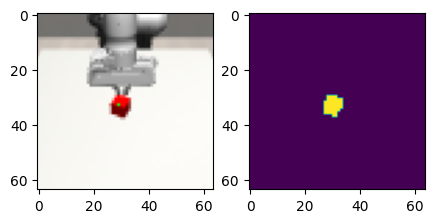

Cube position: [ 0.01666173 -0.02685446  0.8553287 ]
Predicted position: [[-0.05765016 -0.03567131  0.88933593]]
Pixels in view: 41
Contact: False


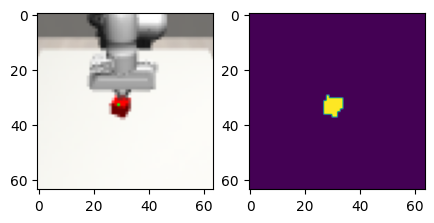

Cube position: [ 0.01666173 -0.02685446  0.8553287 ]
Predicted position: [[-0.05908661 -0.03566932  0.88925135]]
Pixels in view: 36
Contact: False


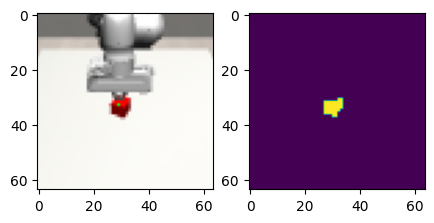

Cube position: [ 0.01653404 -0.02686156  0.85519797]
Predicted position: [[-0.05899436 -0.0359843   0.8896866 ]]
Pixels in view: 39
Contact: False


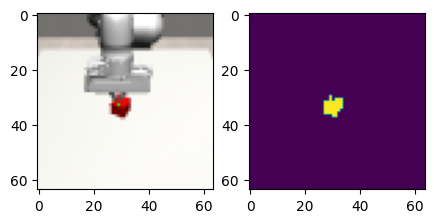

Cube position: [ 0.01662982 -0.02685624  0.855296  ]
Predicted position: [[-0.05767458 -0.03563857  0.8896271 ]]
Pixels in view: 37
Contact: False


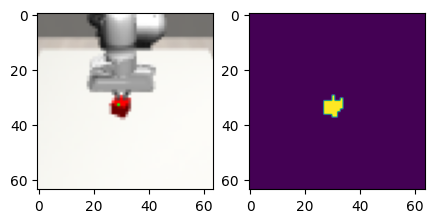

Cube position: [ 0.01666173 -0.02685446  0.8553287 ]
Predicted position: [[-0.05910799 -0.03592731  0.88912666]]
Pixels in view: 39
Contact: False


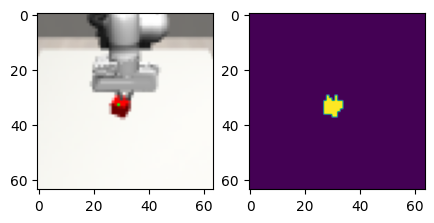

Cube position: [ 0.01671243 -0.02685165  0.85538054]
Predicted position: [[-0.05970519 -0.03641872  0.8893888 ]]
Pixels in view: 38
Contact: True


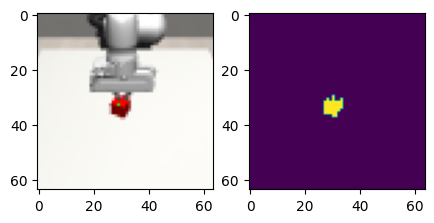

Cube position: [ 0.01234596 -0.02709425  0.8509117 ]
Predicted position: [[-0.0603341  -0.03699659  0.889137  ]]
Pixels in view: 38
Contact: True


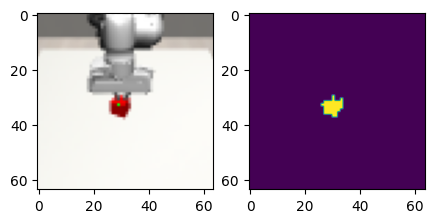

Cube position: [ 0.01914636 -0.02671642  0.85787153]
Predicted position: [[-0.06258985 -0.03737362  0.8887888 ]]
Pixels in view: 39
Contact: True


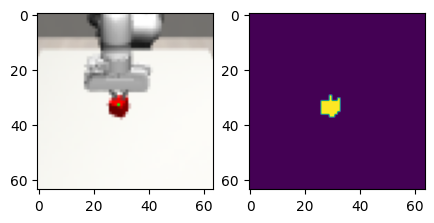

Cube position: [ 0.01586612 -0.03586489  0.8545144 ]
Predicted position: [[-0.06574668 -0.0390131   0.8895425 ]]
Pixels in view: 42
Contact: False


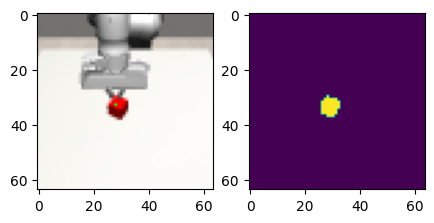

Cube position: [ 0.01647014 -0.03582015  0.8551326 ]
Predicted position: [[-0.06121045 -0.03785703  0.8895478 ]]
Pixels in view: 39
Contact: False


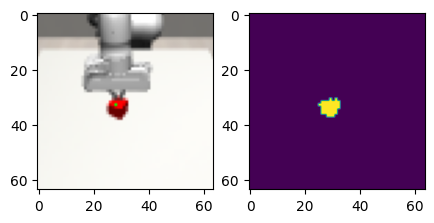

Cube position: [ 0.01661857 -0.03580915  0.8552845 ]
Predicted position: [[-0.05991846 -0.03860302  0.88951343]]
Pixels in view: 42
Contact: False


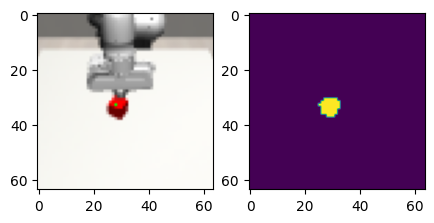

Cube position: [ 0.02563845 -0.03560661  0.85177964]
Predicted position: [[-0.05808757 -0.04185404  0.88928026]]
Pixels in view: 36
Contact: False


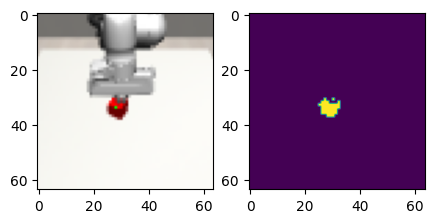

Cube position: [ 0.02472403 -0.03567525  0.85081923]
Predicted position: [[-0.0587483  -0.03942019  0.88932616]]
Pixels in view: 36
Contact: True


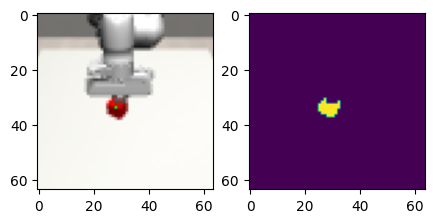

Cube position: [ 0.01621818 -0.03583881  0.85487473]
Predicted position: [[-0.06122268 -0.04162528  0.88957304]]
Pixels in view: 38
Contact: False


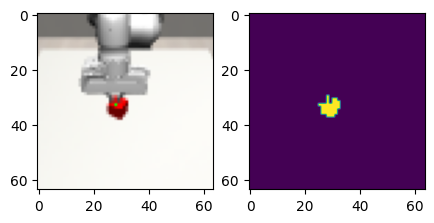

Cube position: [ 0.01655658 -0.03581374  0.85522103]
Predicted position: [[-0.05802593 -0.03887029  0.889251  ]]
Pixels in view: 42
Contact: False


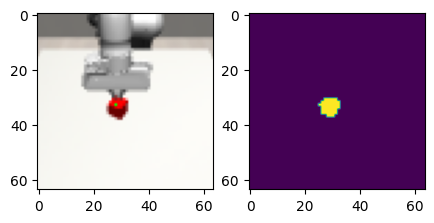

Cube position: [ 0.0166486  -0.03580692  0.8553152 ]
Predicted position: [[-0.05735247 -0.03997914  0.88892895]]
Pixels in view: 43
Contact: False


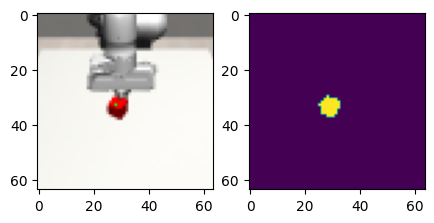

Cube position: [ 0.01668426 -0.03580428  0.85535175]
Predicted position: [[-0.05939486 -0.04389101  0.8888816 ]]
Pixels in view: 40
Contact: True


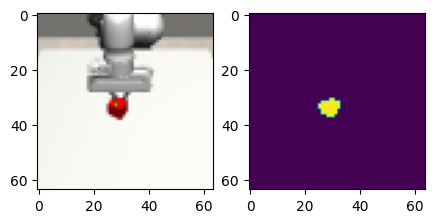

Cube position: [ 0.027989   -0.03543017  0.8542484 ]
Predicted position: [[-0.06016622 -0.04320014  0.8887076 ]]
Pixels in view: 41
Contact: True


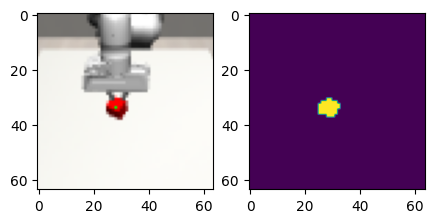

Cube position: [ 0.03172712 -0.03562161  0.84526414]
Predicted position: [[-0.06077592 -0.04295027  0.8892236 ]]
Pixels in view: 30
Contact: True


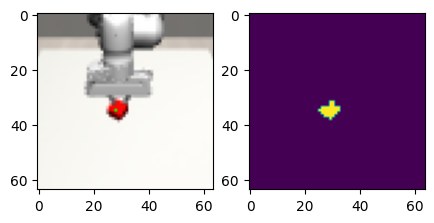

Cube position: [ 0.02497409 -0.03565648  0.85108185]
Predicted position: [[-0.0600681  -0.04257247  0.8892563 ]]
Pixels in view: 42
Contact: True


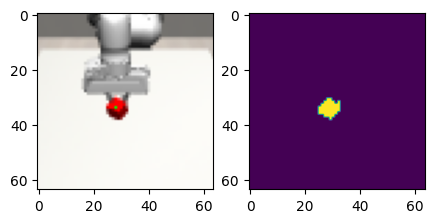

Cube position: [ 0.02213066 -0.03586992  0.8480954 ]
Predicted position: [[-0.05828857 -0.04114245  0.8897593 ]]
Pixels in view: 37
Contact: True


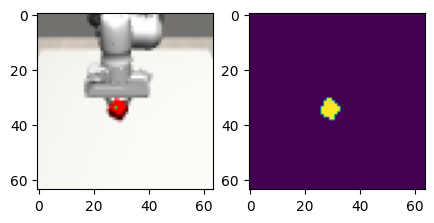

Cube position: [ 0.02938614 -0.03579969  0.8427409 ]
Predicted position: [[-0.05814313 -0.04093415  0.8890658 ]]
Pixels in view: 30
Contact: True


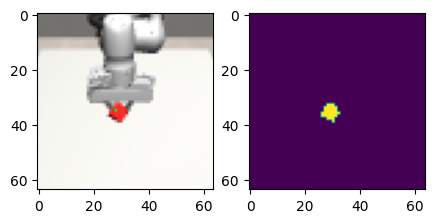

Cube position: [ 0.02617113 -0.03556663  0.85233915]
Predicted position: [[-0.05805495 -0.04000754  0.8904718 ]]
Pixels in view: 37
Contact: False


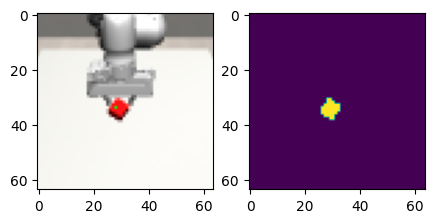

Cube position: [ 0.01701075 -0.0357801   0.8556859 ]
Predicted position: [[-0.05708855 -0.03913172  0.88961095]]
Pixels in view: 46
Contact: False


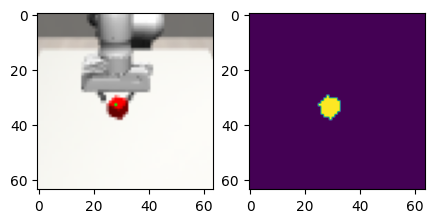

Cube position: [ 0.01664298 -0.03580734  0.8553095 ]
Predicted position: [[-0.05414564 -0.0363813   0.88962495]]
Pixels in view: 45
Contact: False


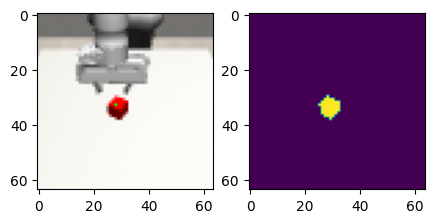

Cube position: [ 0.01665798 -0.03580623  0.8553248 ]
Predicted position: [[-0.05813672 -0.0425518   0.8903557 ]]
Pixels in view: 45
Contact: False


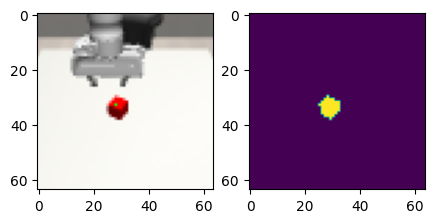

Cube position: [ 0.0166561  -0.03580637  0.8553229 ]
Predicted position: [[-0.05942371 -0.04728356  0.89090294]]
Pixels in view: 45
Contact: False


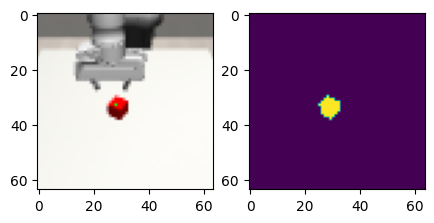

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.05958433 -0.04406752  0.8911959 ]]
Pixels in view: 45
Contact: False


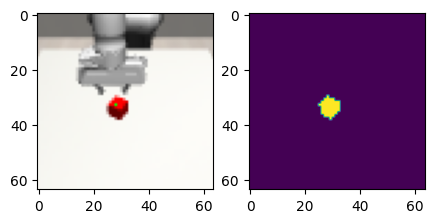

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.05809294 -0.04433791  0.8907253 ]]
Pixels in view: 45
Contact: False


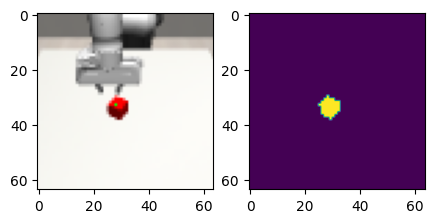

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.05692092 -0.04497528  0.89082   ]]
Pixels in view: 45
Contact: False


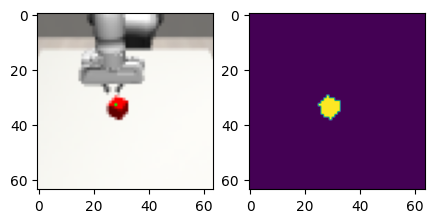

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.06058278 -0.04565266  0.890539  ]]
Pixels in view: 45
Contact: False


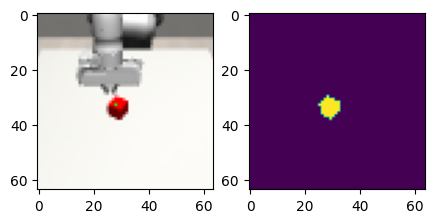

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.05694102 -0.0414131   0.89064044]]
Pixels in view: 45
Contact: False


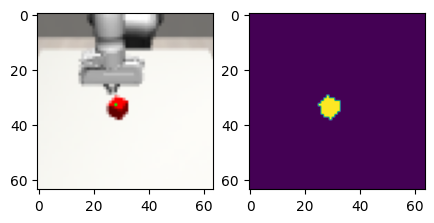

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.05930432 -0.04221205  0.8897633 ]]
Pixels in view: 45
Contact: False


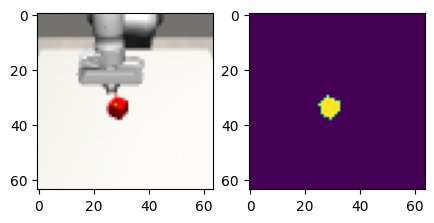

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.05895606 -0.04254241  0.88965327]]
Pixels in view: 45
Contact: False


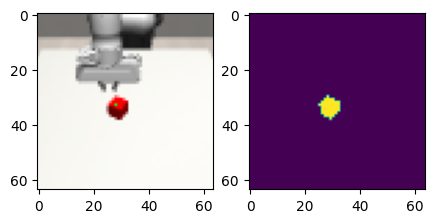

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.05923496 -0.04422832  0.8904648 ]]
Pixels in view: 45
Contact: False


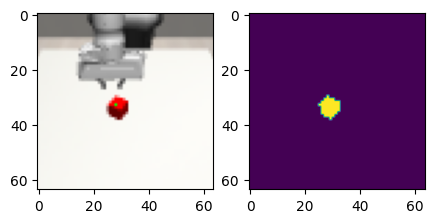

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.05288696 -0.04484341  0.8902738 ]]
Pixels in view: 45
Contact: False


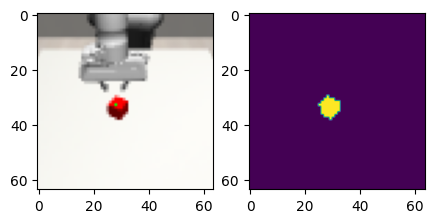

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.05762158 -0.04397982  0.890237  ]]
Pixels in view: 45
Contact: False


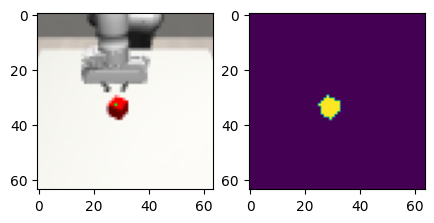

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.05723647 -0.04412337  0.890056  ]]
Pixels in view: 45
Contact: False


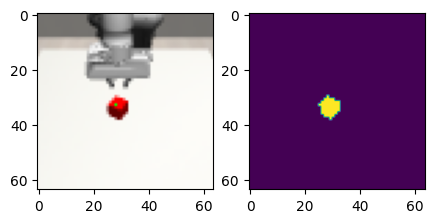

Cube position: [ 0.01665985 -0.03580609  0.8553268 ]
Predicted position: [[-0.06137556 -0.04459941  0.88962775]]
Pixels in view: 45
Contact: False


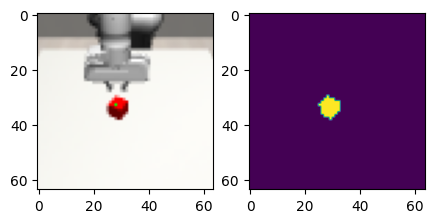

Cube position: [ 0.02585459 -0.03559039  0.8520067 ]
Predicted position: [[-0.06247811 -0.04205929  0.8888151 ]]
Pixels in view: 41
Contact: True


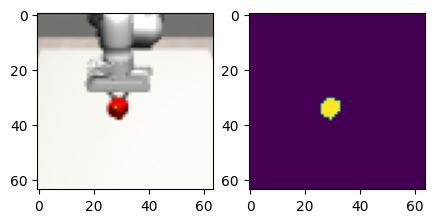

Cube position: [ 0.02090562 -0.03596187  0.8468088 ]
Predicted position: [[-0.06174246 -0.04072563  0.889428  ]]
Pixels in view: 37
Contact: True


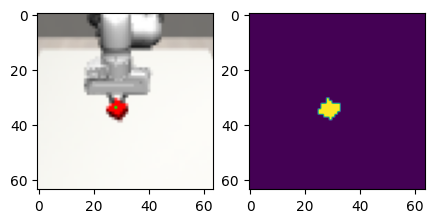

Cube position: [ 0.02882403 -0.0353675   0.8551255 ]
Predicted position: [[-0.06162969 -0.04584804  0.89054394]]
Pixels in view: 38
Contact: False


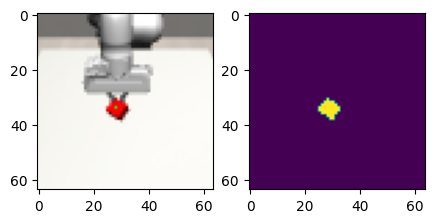

Cube position: [ 0.028578   -0.02653947  0.85486704]
Predicted position: [[-0.05725797 -0.04471895  0.89021575]]
Pixels in view: 34
Contact: False


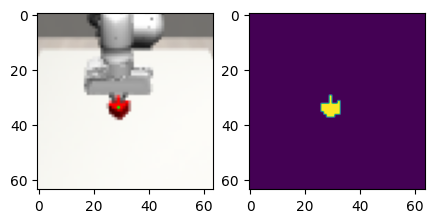

Cube position: [ 0.02885655 -0.02652379  0.85515964]
Predicted position: [[-0.06088474 -0.04484249  0.8893162 ]]
Pixels in view: 35
Contact: False


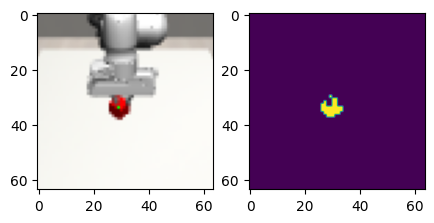

Cube position: [ 0.01660353 -0.0268577   0.8552691 ]
Predicted position: [[-0.05807026 -0.04125993  0.8901698 ]]
Pixels in view: 46
Contact: False


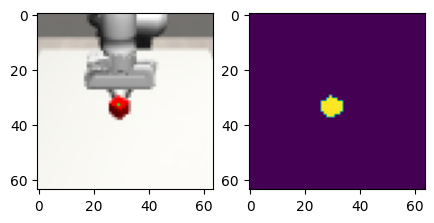

Cube position: [ 0.0166486  -0.02685519  0.8553152 ]
Predicted position: [[-0.05309367 -0.04559086  0.8890711 ]]
Pixels in view: 44
Contact: False


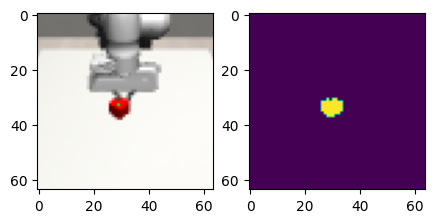

Cube position: [ 0.02895054 -0.0265185   0.85525835]
Predicted position: [[-0.05711561 -0.04702261  0.8900901 ]]
Pixels in view: 39
Contact: False


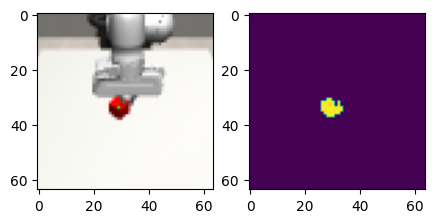

Cube position: [ 0.02895416 -0.0265183   0.8552621 ]
Predicted position: [[-0.06032161 -0.04884426  0.8908898 ]]
Pixels in view: 37
Contact: False


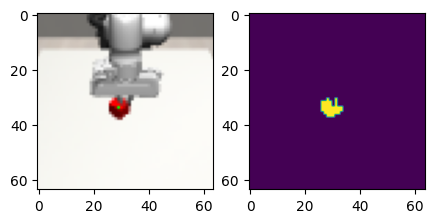

Cube position: [ 0.02895597 -0.02651819  0.855264  ]
Predicted position: [[-0.05653278 -0.04870795  0.88936913]]
Pixels in view: 36
Contact: False


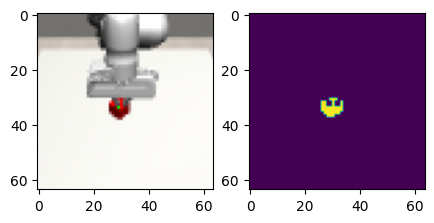

Cube position: [ 0.03830282 -0.025992    0.865081  ]
Predicted position: [[-0.05436866 -0.04400868  0.88971657]]
Pixels in view: 28
Contact: False


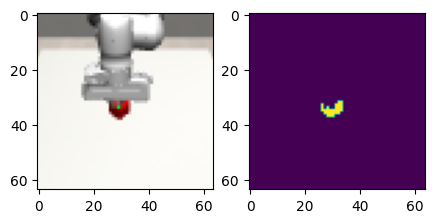

Cube position: [ 0.02166709 -0.02692853  0.84760857]
Predicted position: [[-0.05216726 -0.03927392  0.8902913 ]]
Pixels in view: 34
Contact: True


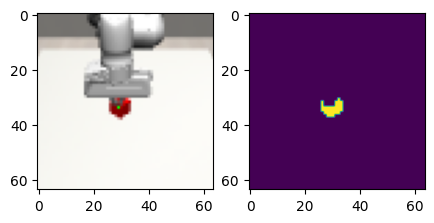

Cube position: [ 0.0324946  -0.02631898  0.85898066]
Predicted position: [[-0.05139323 -0.03938109  0.88894224]]
Pixels in view: 29
Contact: True


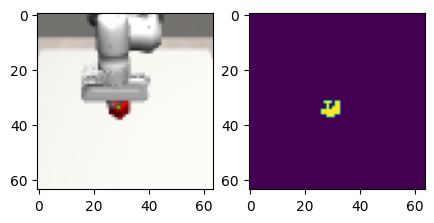

Cube position: [ 0.03606822 -0.02646854  0.8499433 ]
Predicted position: [[-0.04925112 -0.03540528  0.88894975]]
Pixels in view: 25
Contact: True


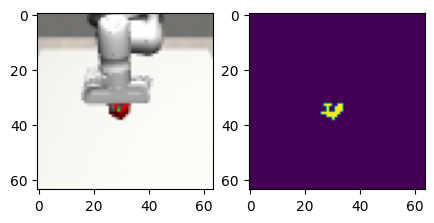

Cube position: [ 0.02164662 -0.02692969  0.84758705]
Predicted position: [[-0.0481002  -0.0380653   0.88914186]]
Pixels in view: 35
Contact: False


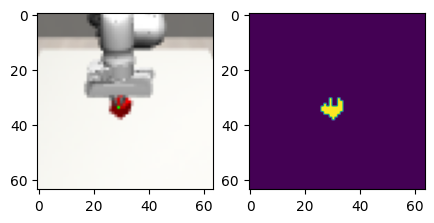

Cube position: [ 0.02693421 -0.02663201  0.8531406 ]
Predicted position: [[-0.03756956 -0.03906571  0.8885871 ]]
Pixels in view: 38
Contact: False


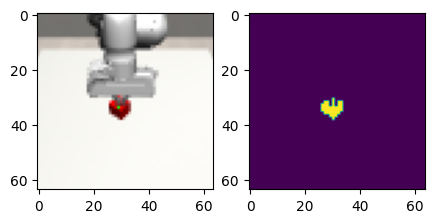

Cube position: [ 0.02838061 -0.02655059  0.85465974]
Predicted position: [[-0.03741365 -0.03556872  0.8889333 ]]
Pixels in view: 34
Contact: False


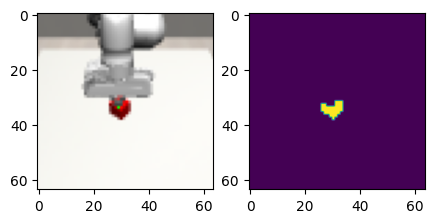

Cube position: [ 0.02881318 -0.02652623  0.85511404]
Predicted position: [[-0.03954764 -0.03798465  0.889307  ]]
Pixels in view: 37
Contact: False


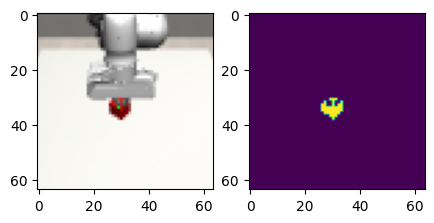

Cube position: [ 0.02881318 -0.02652623  0.85511404]
Predicted position: [[-0.04757554 -0.03616513  0.8891175 ]]
Pixels in view: 21
Contact: False


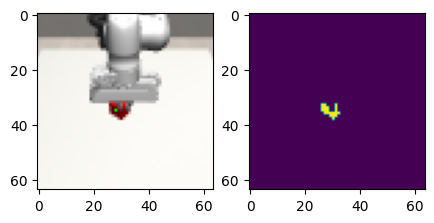

Cube position: [ 0.03842953 -0.02598486  0.8652141 ]
Predicted position: [[-0.05209007 -0.0369826   0.8889742 ]]
Pixels in view: 30
Contact: False


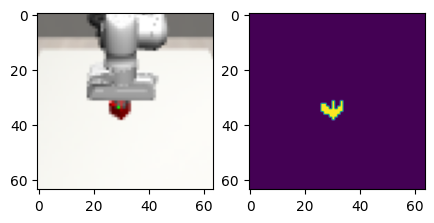

Cube position: [ 0.04053158 -0.01724435  0.86742187]
Predicted position: [[-0.04069551 -0.03833152  0.8889414 ]]
Pixels in view: 31
Contact: False


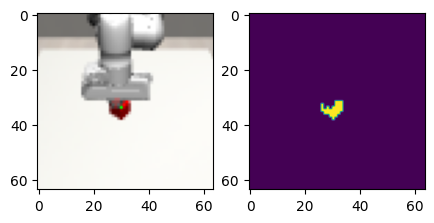

Cube position: [ 0.02895597 -0.02651819  0.855264  ]
Predicted position: [[-0.03032545 -0.03768928  0.88973093]]
Pixels in view: 40
Contact: False


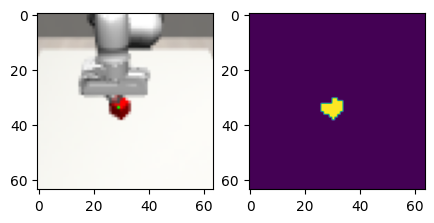

Cube position: [ 0.02895778 -0.02651809  0.8552659 ]
Predicted position: [[-0.0254556  -0.03591085  0.8902812 ]]
Pixels in view: 34
Contact: False


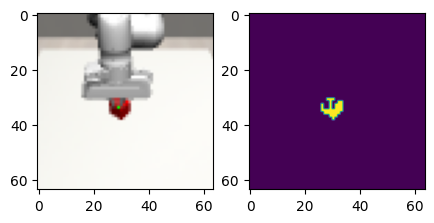

Cube position: [ 0.02895778 -0.02651809  0.8552659 ]
Predicted position: [[-0.04086354 -0.03363611  0.8900728 ]]
Pixels in view: 30
Contact: False


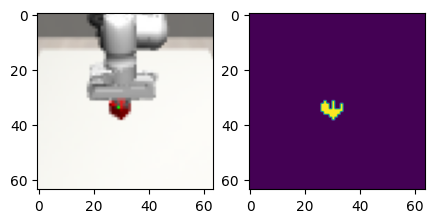

Cube position: [ 0.02749493 -0.02660045  0.8537295 ]
Predicted position: [[-0.04760453 -0.03547326  0.8895555 ]]
Pixels in view: 35
Contact: True


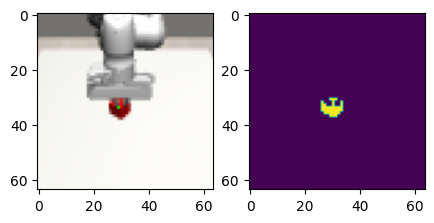

Cube position: [ 0.02749493 -0.02660045  0.8537295 ]
Predicted position: [[-0.04581886 -0.03459928  0.889604  ]]
Pixels in view: 22
Contact: True


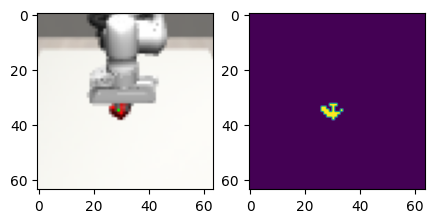

Cube position: [ 0.03570553 -0.02648923  0.84955233]
Predicted position: [[-0.05013353 -0.03606173  0.8887639 ]]
Pixels in view: 25
Contact: False


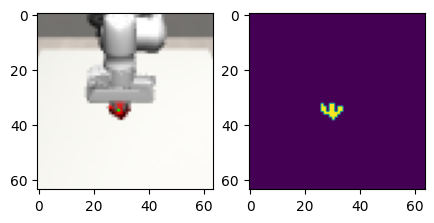

Cube position: [ 0.01662044 -0.02685676  0.8552864 ]
Predicted position: [[-0.04248333 -0.03496181  0.88968515]]
Pixels in view: 39
Contact: False


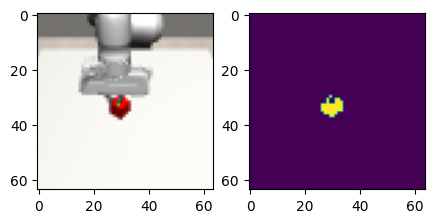

Cube position: [ 0.01665985 -0.02685457  0.8553268 ]
Predicted position: [[-0.03203163 -0.03410537  0.89029264]]
Pixels in view: 45
Contact: False


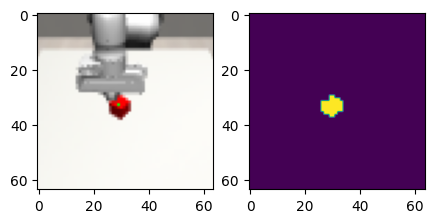

Cube position: [ 0.0166636  -0.02685436  0.8553306 ]
Predicted position: [[-0.03385957 -0.03303359  0.89098895]]
Pixels in view: 45
Contact: False


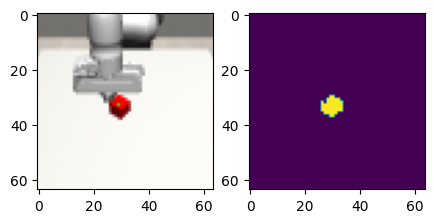

Cube position: [ 0.01665985 -0.02685457  0.8553268 ]
Predicted position: [[-0.03887375 -0.02952048  0.89210117]]
Pixels in view: 45
Contact: False


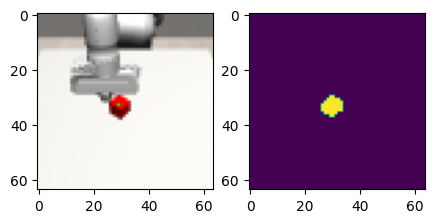

Cube position: [ 0.01666739 -0.02685415  0.85533446]
Predicted position: [[-0.05261394 -0.02868221  0.89223576]]
Pixels in view: 44
Contact: False


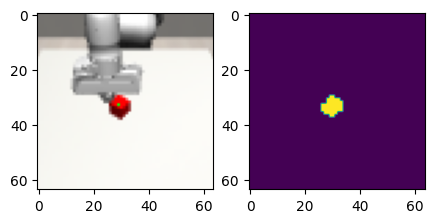

Cube position: [ 0.01666927 -0.02685405  0.85533637]
Predicted position: [[-0.05460556 -0.02838065  0.8923532 ]]
Pixels in view: 46
Contact: False


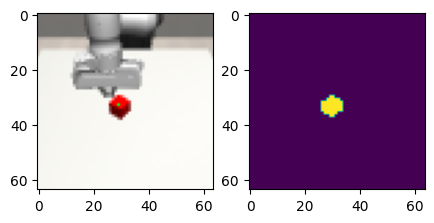

Cube position: [ 0.01667114 -0.02685394  0.8553383 ]
Predicted position: [[-0.05319694 -0.0338513   0.8926176 ]]
Pixels in view: 46
Contact: False


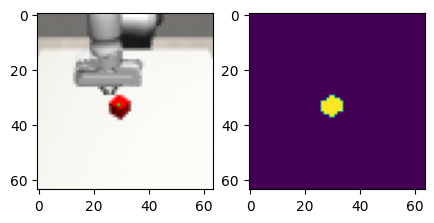

Cube position: [ 0.01666927 -0.02685405  0.85533637]
Predicted position: [[-0.05282736 -0.03233369  0.8923852 ]]
Pixels in view: 45
Contact: True


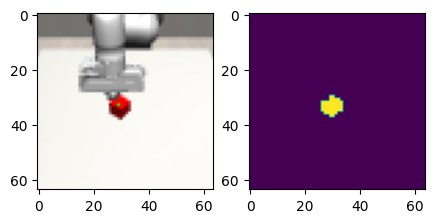

Cube position: [ 0.01639381 -0.03630054  0.84207004]
Predicted position: [[-0.06305166 -0.03118881  0.8914531 ]]
Pixels in view: 33
Contact: True


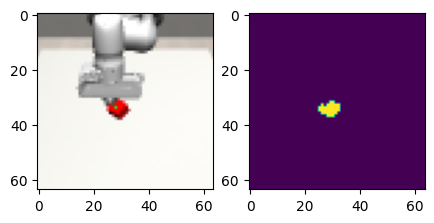

Cube position: [ 0.02495756 -0.03565772  0.8510645 ]
Predicted position: [[-0.06224478 -0.03368669  0.89031446]]
Pixels in view: 39
Contact: True


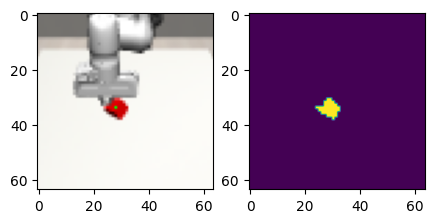

Cube position: [ 0.02628629 -0.03555799  0.8524601 ]
Predicted position: [[-0.05893409 -0.03730565  0.88994545]]
Pixels in view: 42
Contact: True


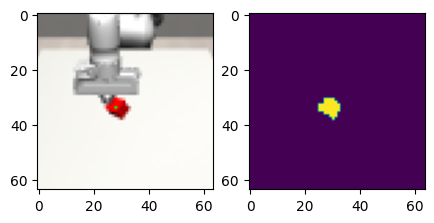

Cube position: [ 0.01611657 -0.02688475  0.8547707 ]
Predicted position: [[-0.05021842 -0.03716376  0.8888506 ]]
Pixels in view: 46
Contact: False


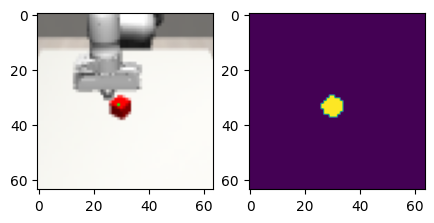

Cube position: [ 0.01661103 -0.02685728  0.85527676]
Predicted position: [[-0.05078838 -0.03796255  0.88912827]]
Pixels in view: 44
Contact: False


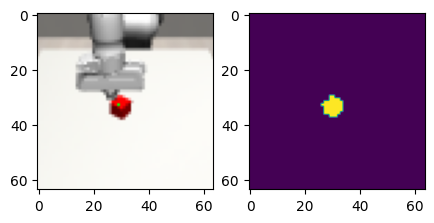

Cube position: [ 0.01665235 -0.02685498  0.8553191 ]
Predicted position: [[-0.05428835 -0.03324862  0.8895868 ]]
Pixels in view: 42
Contact: False


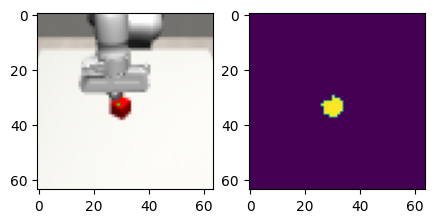

Cube position: [ 0.02895054 -0.017679    0.85525835]
Predicted position: [[-0.05598159 -0.03135128  0.88992506]]
Pixels in view: 31
Contact: False


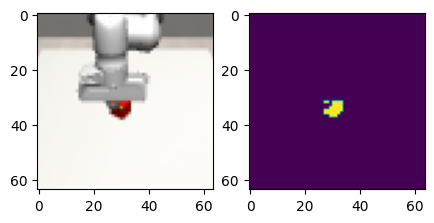

Cube position: [ 0.02895054 -0.017679    0.85525835]
Predicted position: [[-0.05547795 -0.03265746  0.8883861 ]]
Pixels in view: 20
Contact: True


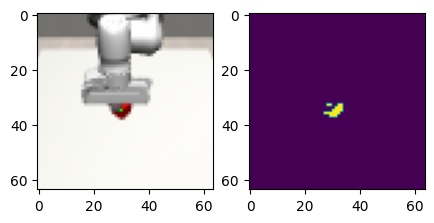

Cube position: [ 0.02765124 -0.01772776  0.8538937 ]
Predicted position: [[-0.0487104  -0.03841335  0.8878052 ]]
Pixels in view: 29
Contact: False


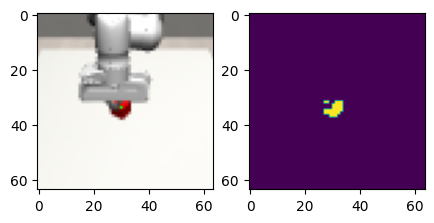

Cube position: [ 0.0259205  -0.02668908  0.8520759 ]
Predicted position: [[-0.02237909 -0.04398546  0.8882979 ]]
Pixels in view: 38
Contact: False


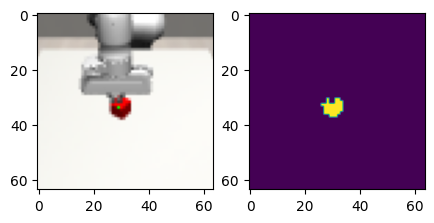

Cube position: [ 0.02552477 -0.02671136  0.85166025]
Predicted position: [[-0.01851011 -0.03641549  0.89022946]]
Pixels in view: 37
Contact: False


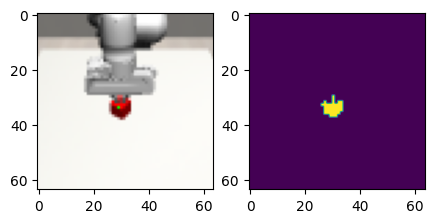

Cube position: [ 0.02892345 -0.01768002  0.85522985]
Predicted position: [[-0.04076564 -0.03065962  0.8888179 ]]
Pixels in view: 33
Contact: True


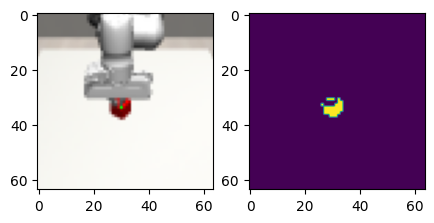

100%|██████████| 1/1 [00:24<00:00, 24.03s/it]


In [12]:
# get first observation from env (reset), feed it to encoder and get feat, feed features to actor for planning sequence, swap features to test out different objects
import utils
%matplotlib inline
from IPython import display
import imageio

newpath = r'./temp' 
if not os.path.exists(newpath):
    os.makedirs(newpath)

render_size = 64
camera = "agentview"

eval_mode = True

agent_state = None
meta = agent.init_meta()

dreamer_obs = eval_env.reset()
episodes = 1

step, episode, total_reward = 0, 0, 0

reward_fn = (
    lambda seq: agent.wm.heads["object_decoder"](
        seq["feat"], only_mlp=True
    )["objects_pos"][0]
    .mean[:, :, 1]
    .unsqueeze(-1)
) 
        
for ep in tqdm(range(episodes)):
    agent_state = None
    dreamer_obs = eval_env.reset()
    
    with torch.no_grad(), utils.eval_mode(agent):
        while not bool(dreamer_obs['is_last']):
            f, axs = plt.subplots(1, 2, figsize=(5, 5))
            action, agent_state = agent.act(
                                    dreamer_obs,
                                    meta,
                                    step,
                                    eval_mode=False,
                                    state=agent_state,
                                )
        
            dreamer_obs = eval_env.step(action)
        
            seg_pixels = np.argwhere(dreamer_obs["segmentation"][0])
            if len(seg_pixels) > 0:
                centroid = np.mean(seg_pixels, axis=0).astype(int)
                dreamer_obs["rgb"][:, centroid[0], centroid[1]] = [0,255,0]

            axs[0].imshow(dreamer_obs["rgb"].transpose(1,2,0))    
            axs[1].imshow(dreamer_obs["segmentation"][0])
            
            pos = dreamer_obs["objects_pos"]
            print(f"Cube position: {pos[0]}")
            # axs[1].set_title(f"{pos[0]}")
            
            feat = agent.wm.rssm.get_feat(agent_state[0]).unsqueeze(0)
            # print(
            predicted_pos = agent.wm.heads["object_decoder"](feat, only_mlp=True)["objects_pos"].mean
            
            print(f"Predicted position: {predicted_pos[0, 0].cpu().numpy()}")
            print(f"Pixels in view: { len(seg_pixels)}")
            
            contact = eval_env._env.check_contact(eval_env._env.robots[0].gripper, eval_env._env.cube)
            print(f"Contact: {contact}")
            
            plt.savefig(f'./temp/img_{step}.png', transparent = False, facecolor="white", bbox_inches='tight')
            plt.show()
        
            step += 1
    
    episode += 1
    
    frames = []
    
    for t in range(step):
        image = imageio.v2.imread(f'./temp/img_{t}.png')
        frames.append(image)
        
    imageio.mimsave('./out.gif', # output gif
                frames,          # array of input frames
                fps = 20)  
